# Supplementary Figures

This notebook contains code to generate the additional supplementary figures. Note that some additional figures corresponding to experiments in the main figures can be found in the respective notebooks `figure{i}.ipynb`.

In [1]:
from common import *

from collections import defaultdict
from uncertainties import ufloat
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
from sklearn import metrics
from models.ops import filter_array_by_distance
from scipy.stats import zscore, mannwhitneyu
import matplotlib
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple

2026-02-11 16:53:01.945755: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-11 16:53:01.967259: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-11 16:53:01.967297: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-11 16:53:01.981184: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-11 16:53:03.173674: W tensorflow/compiler/tf

In [2]:
get(
    "machinable.index",
    "./index",
).__enter__()

machinable.index [a578b7]

## All cells

In [29]:
baseline_hvs = restore("figure3-baseline_hvs")
igds = restore("figure3-igds")
nos_hv = restore("figure3-nos_hv")
initial_samples = restore("figure3-initial_samples")

/tmp/ipykernel_2696709/174654505.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


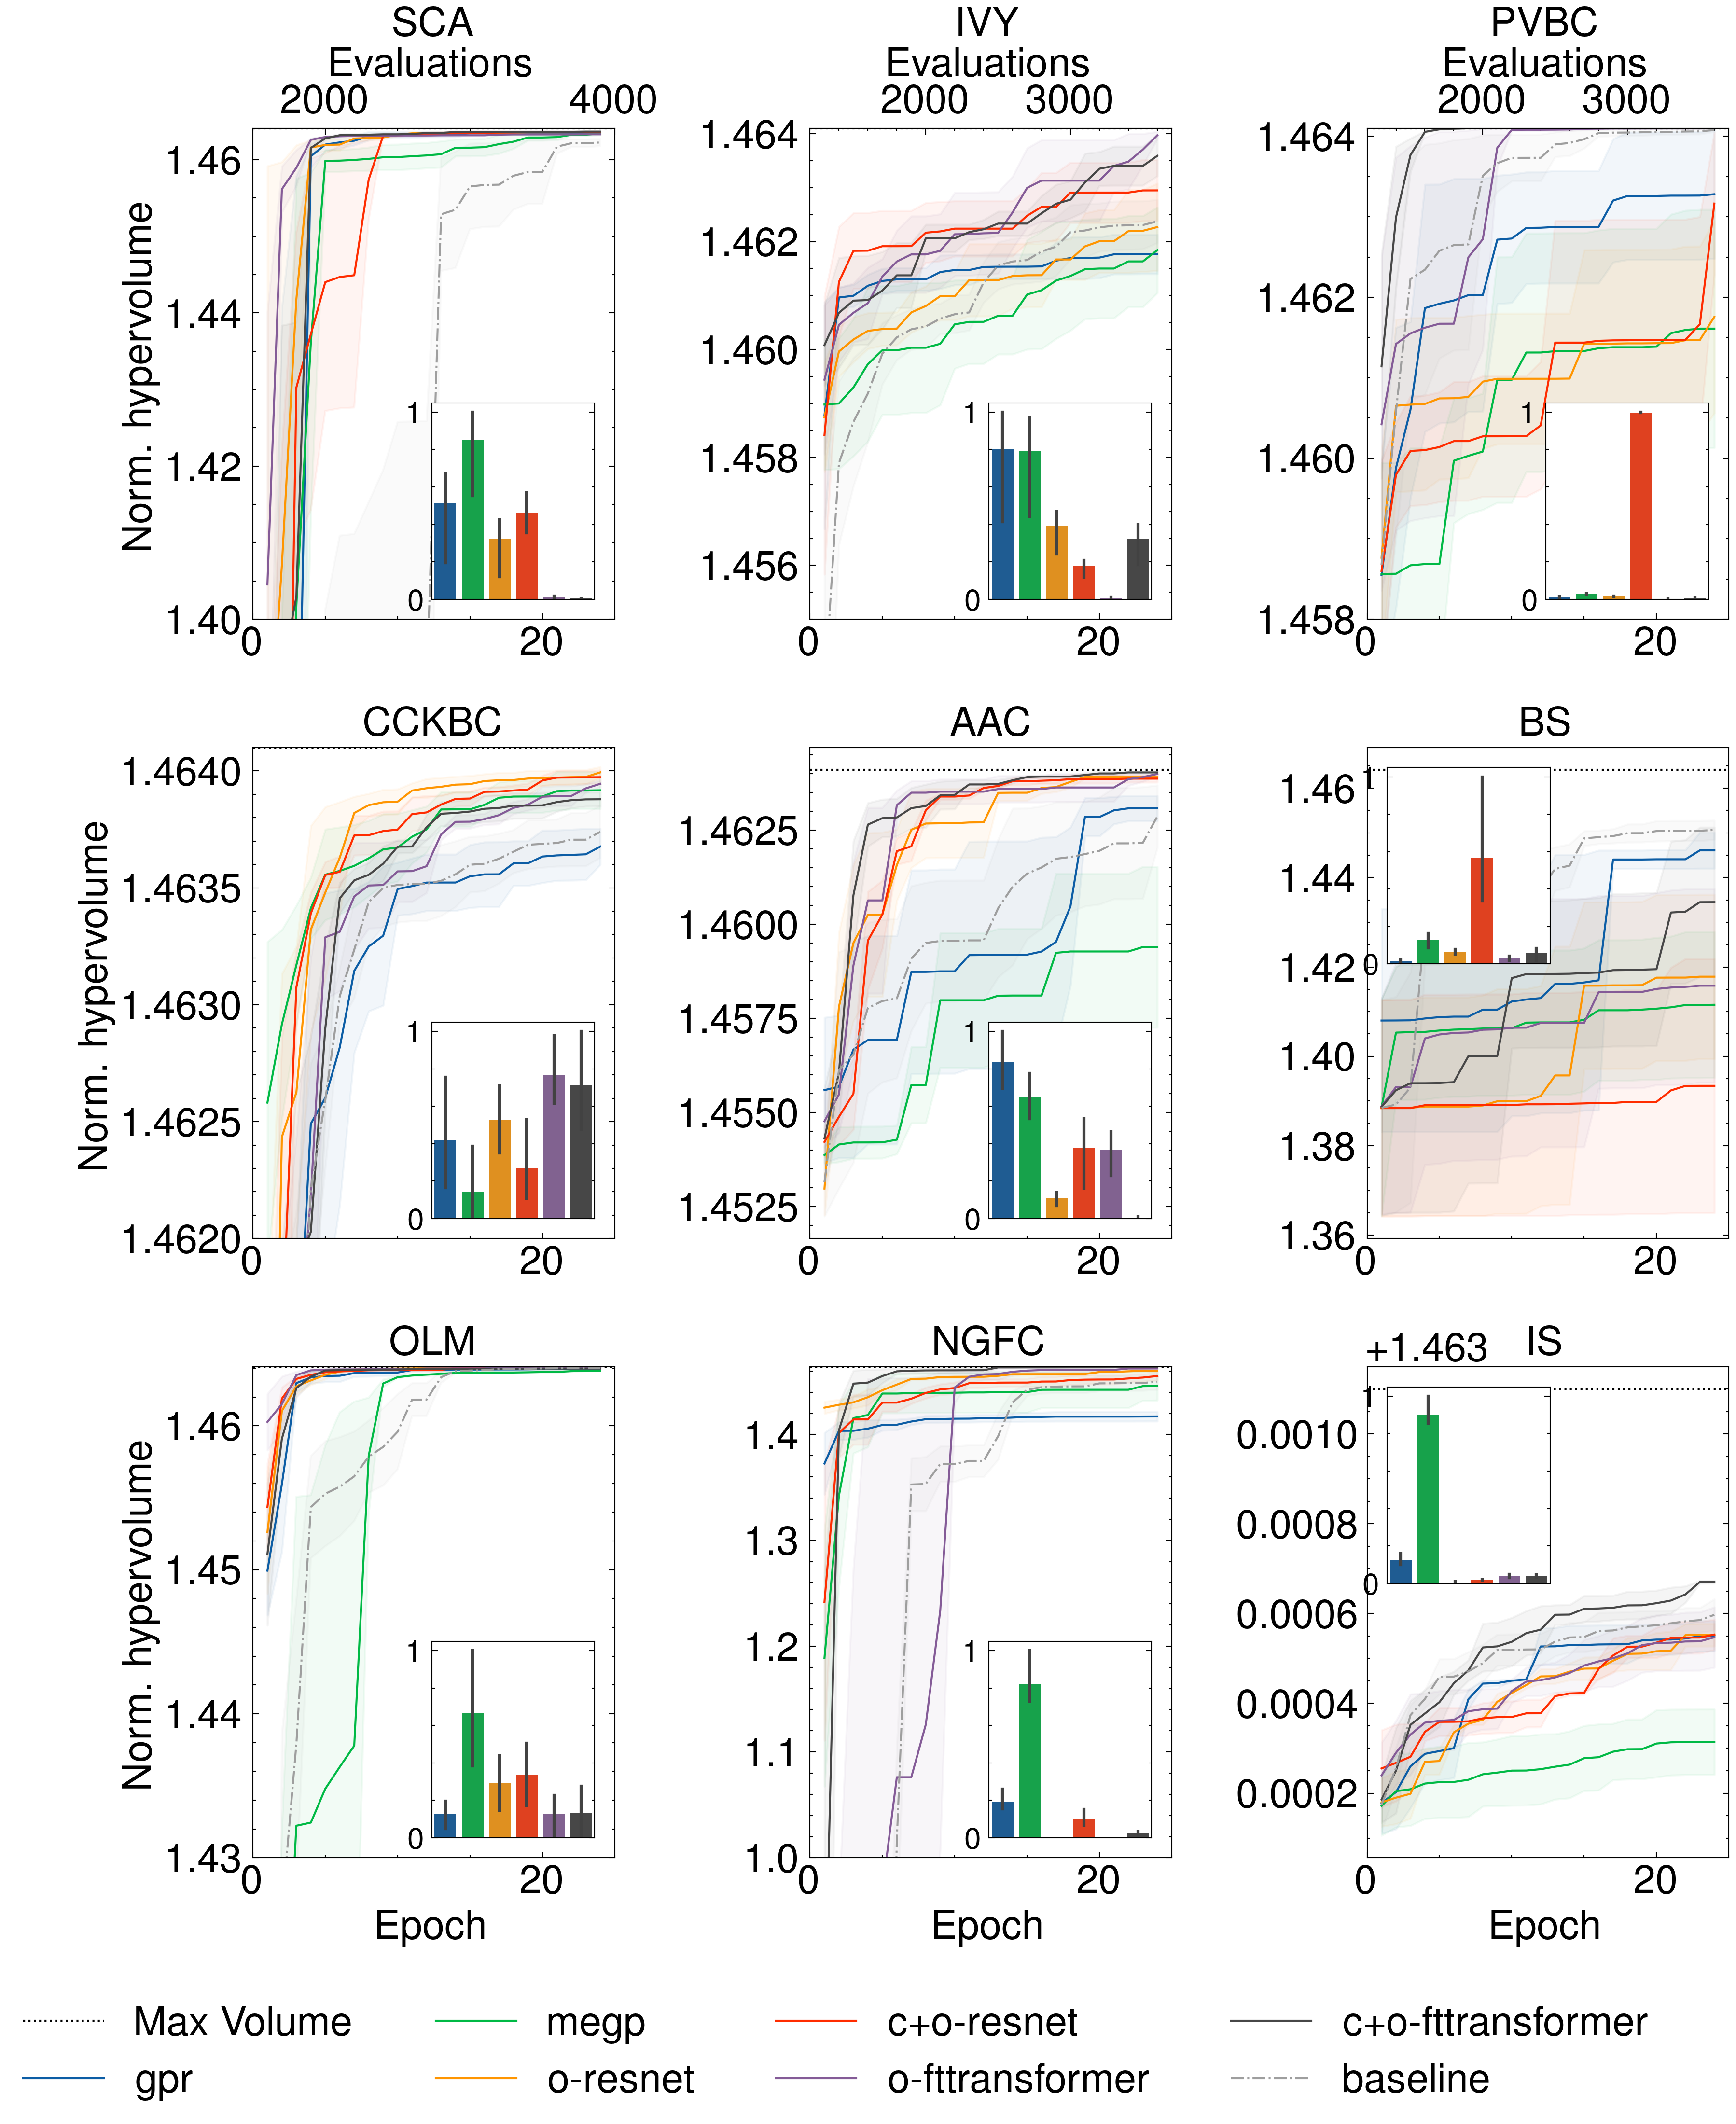

In [64]:
populations_all = ["SCA", "IVY", "PVBC", "CCKBC", "AAC", "BS", "OLM", "NGFC", "IS"]

with rc_context():
    plt.rcParams["xtick.top"] = False
    plt.rcParams["ytick.left"] = True
    plt.rcParams["ytick.right"] = True

    fig, axs = plt.subplots(3, 3, figsize=(12, 14), sharey=False)

    for ax, p in zip(axs.flatten(), populations_all):
        if p not in baseline_hvs:
            ax.set_title(f"{p} (no data)")
            ax.set_visible(False)
            continue

        models = baseline_hvs[p]

        ax.axhline(y=1.1**4, color="black", linestyle=":", label="Max Volume")

        converged = {}
        for i, (model_name, epoch_hvs) in enumerate(models.items()):
            for epoch, hvs in epoch_hvs.items():
                epoch = int(epoch)
                converged[model_name] = [0]
                if epoch > 1 and np.mean(hvs) > 0.99 * np.mean(
                    baseline_hvs[p]["baseline"]["24"]
                ):
                    converged[model_name] = [24 - epoch]
                    break

        for i, (model_name, epoch_hvs) in enumerate(models.items()):
            x = []
            y = []
            y_err = []
            for epoch, hvs in epoch_hvs.items():
                epoch = int(epoch)
                if epoch == 0 or epoch > 100:
                    continue
                x.append(epoch)
                y.append(np.mean(hvs))
                y_err.append(stats.sem(hvs))

            y = np.array(y)
            y_err = np.array(y_err)

            ax.plot(
                x,
                y,
                color=icolors[i],
                label=model_name,
                linestyle="-" if model_name != "baseline" else "dashdot",
            )
            ax.fill_between(x, y - y_err, y + y_err, alpha=0.05, color=icolors[i])

        # IGD inset
        if p in igds and len(igds[p]) > 1:
            axigd = inset_axes(
                ax,
                width="45%",
                height="40%",
                loc="lower right" if p not in ["BS", 'IS'] else "upper left",
            )
            igd_df = pd.DataFrame(igds[p])
            if "-" in igd_df.columns:
                igd_df = igd_df.drop("-", axis=1)
            igd_min = igd_df.min().min()
            igd_max = igd_df.max().max()
            if igd_max > igd_min:
                igd_df = (igd_df - igd_min) / (igd_max - igd_min)
            else:
                igd_df = igd_df * 0
            sns.barplot(igd_df, ax=axigd)
            #axigd.set_title("Norm. IGD", loc="right", y=1.0, pad=-6, fontsize=12)
            axigd.tick_params(top=False, bottom=False, left=True, right=True, labelsize=15)
            axigd.set_xticks([])
            axigd.set_yticks([0, 1])

        if p in ['OLM', 'NGFC', 'IS']:
            ax.set_xlabel("Epoch")
        ax.set_xlim([0, 25])
        ax.tick_params(top=False)

        lims = {'SCA': 1.4, 
                'IVY': 1.455, 
                'PVBC': 1.458,
                 'CCKBC': 1.462,
                 'OLM': 1.43, 
                 'NGFC': 1.0,
                 }
        if p in lims:
            ax.set_ylim([lims[p], 1.1**4])

        if p in initial_samples and p in ['SCA', 'IVY', 'PVBC']:
            secax = ax.secondary_xaxis(
                "top",
                functions=(
                    lambda x, ins=initial_samples[p]: x * 100 + ins,
                    lambda x, ins=initial_samples[p]: (x + ins) / 100,
                ),
            )
            
            secax.set_xlabel("Evaluations")

        ax.set_title(p)
    
    for ax in axs[:, 0]:
        ax.set_ylabel("Norm. hypervolume")

    handles, labels = axs[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, ncol=len(labels)//2, bbox_to_anchor=(0.95, 0.01))
    plt.tight_layout()
    plt.show()

In [65]:
stash("supplementary/figure-all-populations-convergence", fig)

/tmp/ipykernel_2696709/758292266.py:76: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


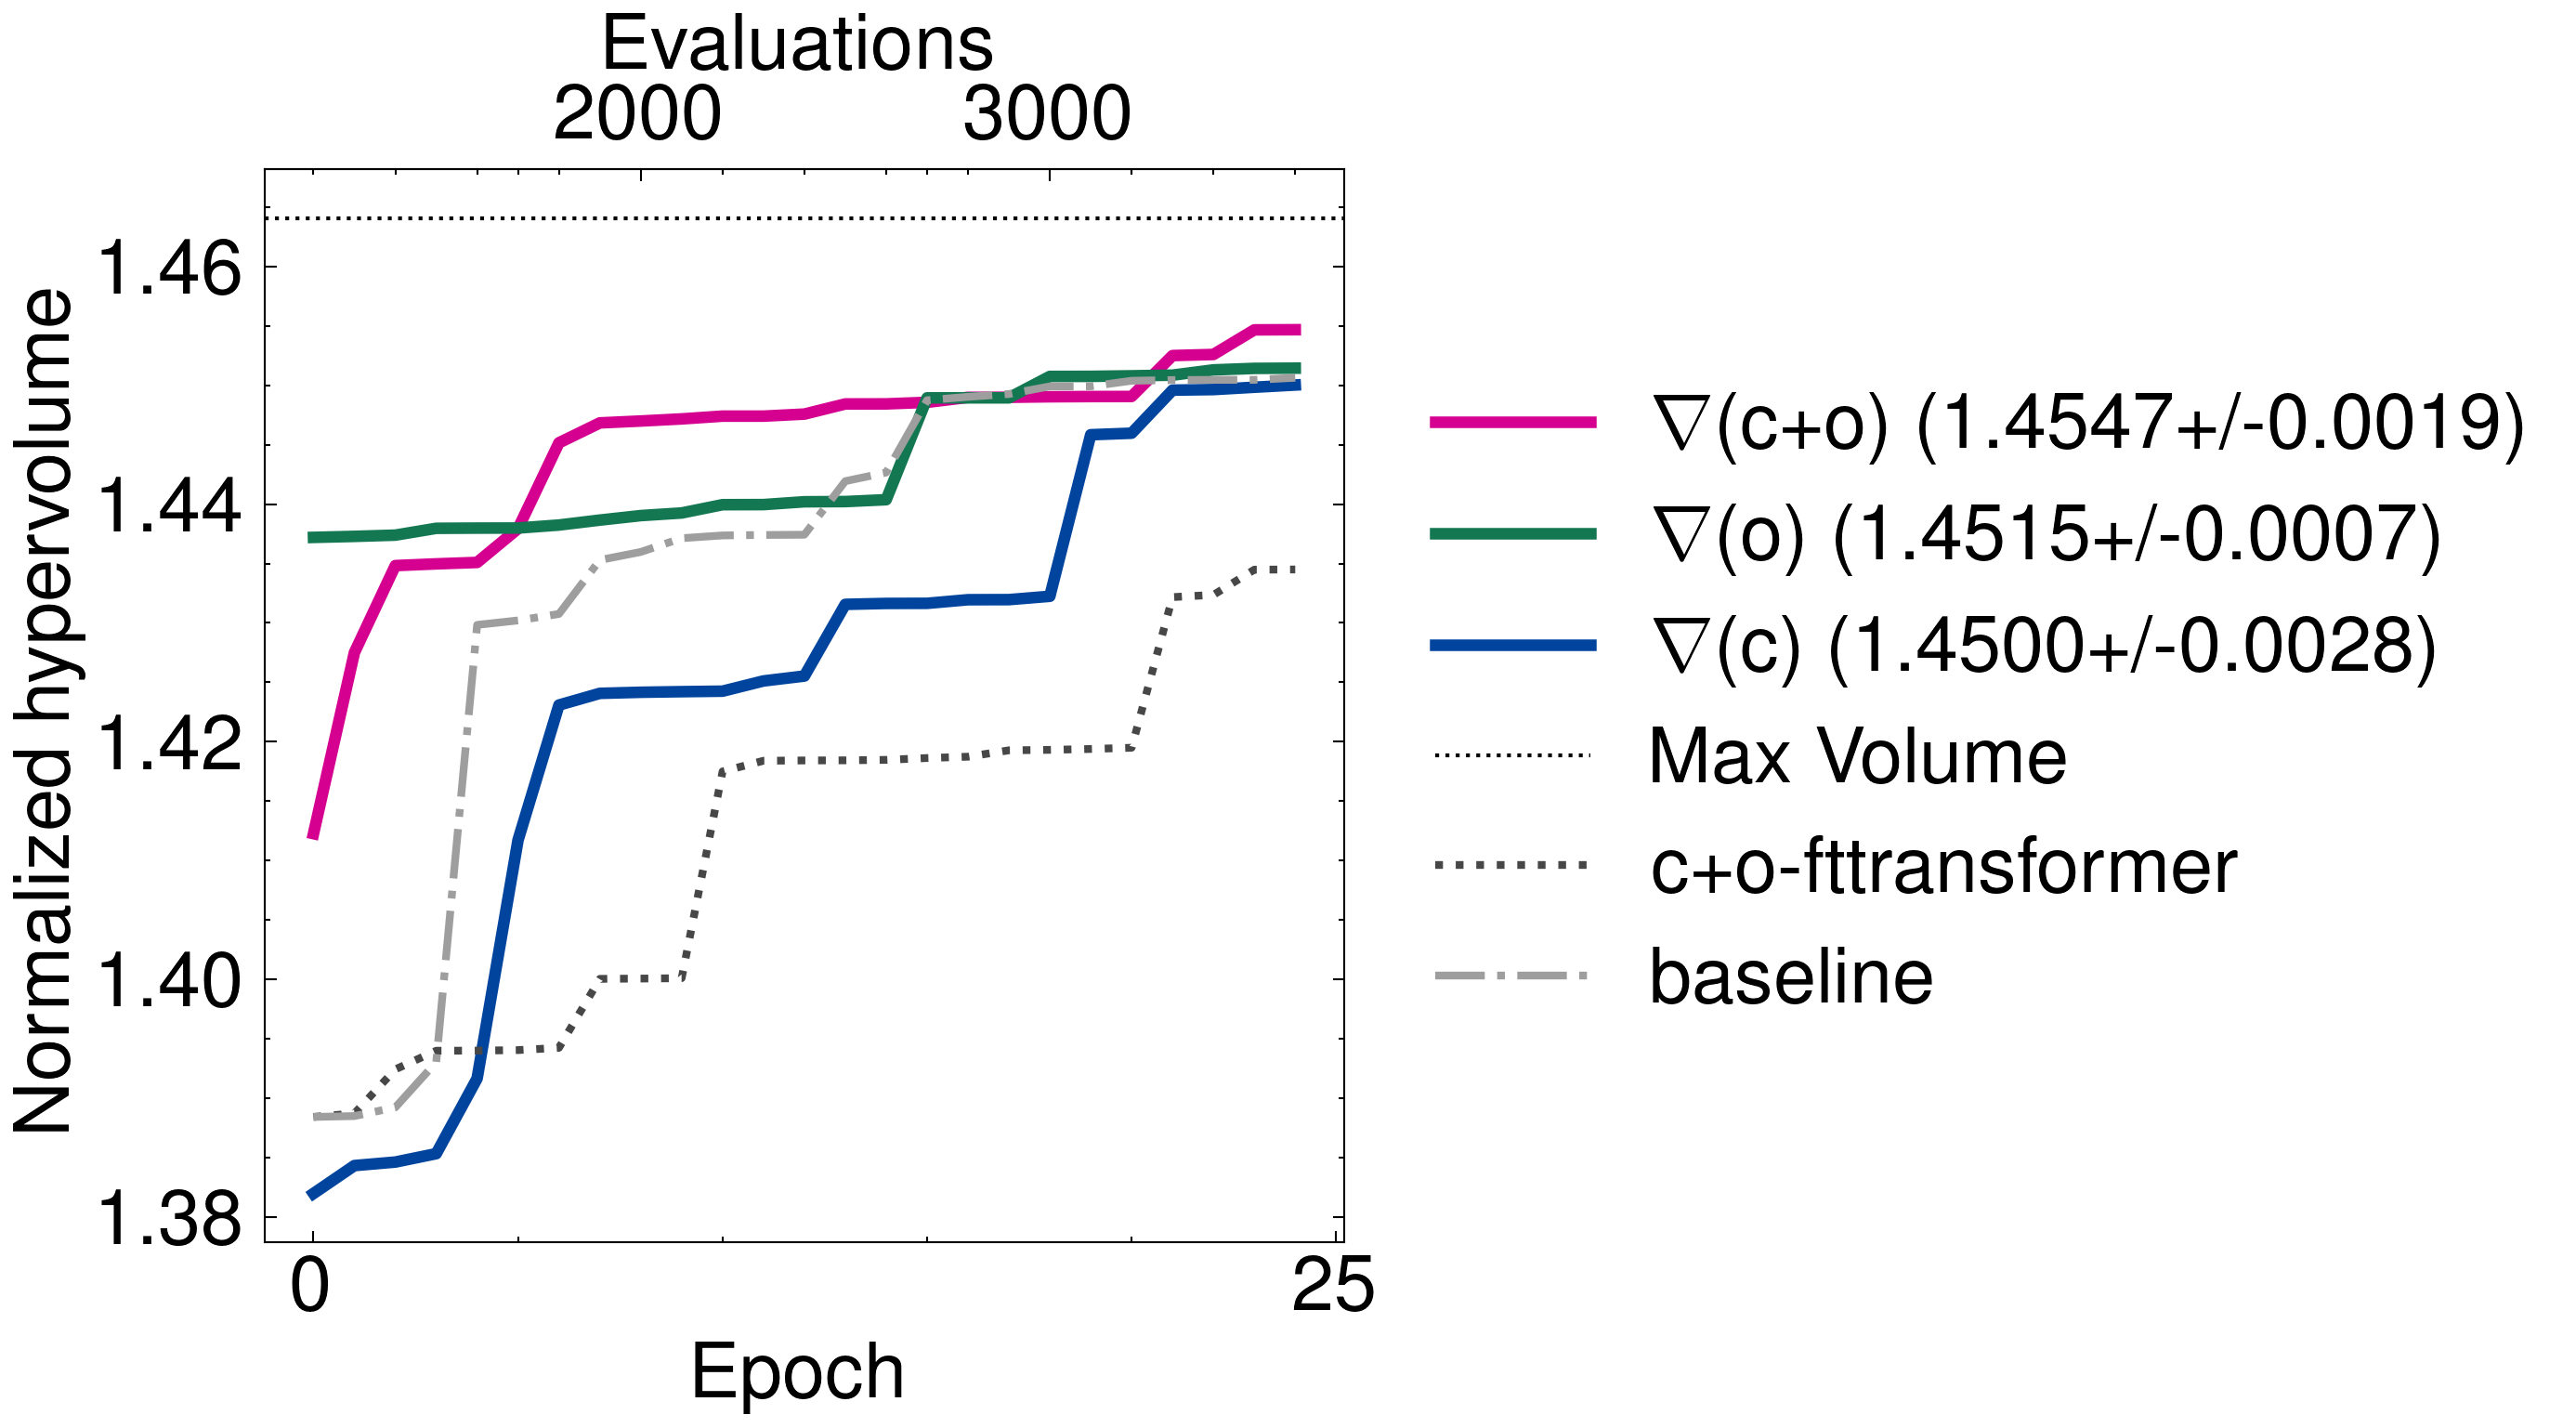

In [68]:
bs_hvs = restore("figure3-bs_hvs")

with rc_context():
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.axhline(y=1.1**4, color="black", linestyle=":", label="Max Volume")

    grad_colors = {
        "objective constraint": "#D5008F",
        "objective": "#137752",
        "constraint": "#00449E",
    }
    grad_labels = {
        "objective constraint": "$\\nabla$(c+o)",
        "objective": "$\\nabla$(o)",
        "constraint": "$\\nabla$(c)",
    }

    for model_name, epoch_hvs in bs_hvs.items():
        if "distance" in model_name:
            continue
        x = []
        y = []
        y_err = []
        for epoch, hvs in epoch_hvs.items():
            x.append(int(epoch))
            y.append(np.mean(hvs))
            y_err.append(stats.sem(hvs))

        label = grad_labels.get(model_name, model_name)
        color = grad_colors.get(model_name, colors["grey"])

        ax.plot(
            x, y,
            label=f"{label} ({ufloat(y[-1], y_err[-1])})",
            color=color,
            linewidth=3,
        )

    # Add baselines from figure3 for BS
    if "BS" in baseline_hvs:
        for ref_model, ref_style in [
            ("c+o-fttransformer", "dotted"),
            ("baseline", "dashdot"),
        ]:
            if ref_model in baseline_hvs["BS"]:
                y_ref = [np.mean(hvs) for hvs in baseline_hvs["BS"][ref_model].values()]
                ax.plot(
                    x[:len(y_ref)], y_ref,
                    label=ref_model,
                    color=mcolors.get(ref_model, colors["grey"]),
                    linestyle=ref_style,
                    linewidth=2,
                )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Normalized hypervolume")
    ax.set_xticks([0, 25])
    ax.tick_params(top=False)

    if "BS" in initial_samples:
        secax = ax.secondary_xaxis(
            "top",
            functions=(
                lambda x, ins=initial_samples["BS"]: x * 100 + ins,
                lambda x, ins=initial_samples["BS"]: (x + ins) / 100,
            ),
        )
        secax.set_xlabel("Evaluations")

    handles, labels = ax.get_legend_handles_labels()
    pairs = sorted(zip(handles, labels), key=lambda x: -float(x[1].split("(")[-1].split("+/-")[0]) if "+/-" in x[1] else 0)
    if pairs:
        handles, labels = zip(*pairs)
    ax.legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

    plt.tight_layout()
    plt.show()


In [69]:
stash("supplementary/bs-gradient-convergence", fig)

## Superfront

In [3]:
from nds import ndomsort

_ca1_sopt_baseline = get("interface._ca1_sopt_baseline", {"selection": (None,)})

globus_download(_ca1_sopt_baseline)

numprocs=1


In [5]:
def _name(experiment):
    n = (
        experiment.label()
        .split("_neuron::")[-1][2:]
        .split("/")[0]
        .replace("joint-", "")
    )
    if "o" in n:
        n += (
            "-"
            + experiment.config.dopt_params.surrogate_custom_training_kwargs.backbone
        )
    return n


populations_sf = ["SCA", "IVY", "PVBC", "CCKBC", "AAC", "BS", "OLM"]

superfront_data = {}
names = None
bars = defaultdict(list)

for population in populations_sf:
    experiments = _ca1_sopt_baseline.components.filter(
        lambda x: population in x.label()
        and not x.load_attribute("preflight", False)
        and x.cached()
    )

    pf_sizes = {}
    labels = []
    seq = []
    for e, experiment in enumerate(experiments):
        lbl = _name(experiment)
        if lbl == "-":
            continue  # skip baseline (no-surrogate)
        pf = experiment.get_best(epsilon=None)["y"].to_numpy()
        pf_sizes[lbl] = len(pf)
        for i in range(pf.shape[0]):
            if np.any(np.isnan(pf[i])):
                continue
            seq.append(list(pf[i]))
            labels.append(lbl)

    if len(seq) == 0:
        continue

    front_indices = np.array(ndomsort.non_domin_sort(seq, only_front_indices=True))
    labels = np.array(labels)

    if names is None:
        names = sorted(np.unique(labels))

    pareto_mask = front_indices == 0
    pareto_labels = labels[pareto_mask]
    num_total = len(pareto_labels)
    unique_labels, counts = np.unique(pareto_labels, return_counts=True)

    percentages = counts / num_total * 100

    for n in names:
        flag = False
        for l, p in zip(unique_labels, percentages):
            if n == l:
                flag = True
                bars[n].append(p)
                break
        if not flag:
            bars[n].append(0)

superfront_data = {"names": names, "bars": dict(bars), "populations": populations_sf}


In [7]:
stash("supplementary-superfront_data", superfront_data)

In [8]:
superfront_data = restore("supplementary-superfront_data")

<>:22: SyntaxWarning: invalid escape sequence '\%'
<>:22: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_2696709/2529763447.py:22: SyntaxWarning: invalid escape sequence '\%'
  ax.set_xlabel("Superfront contribution (\%)")


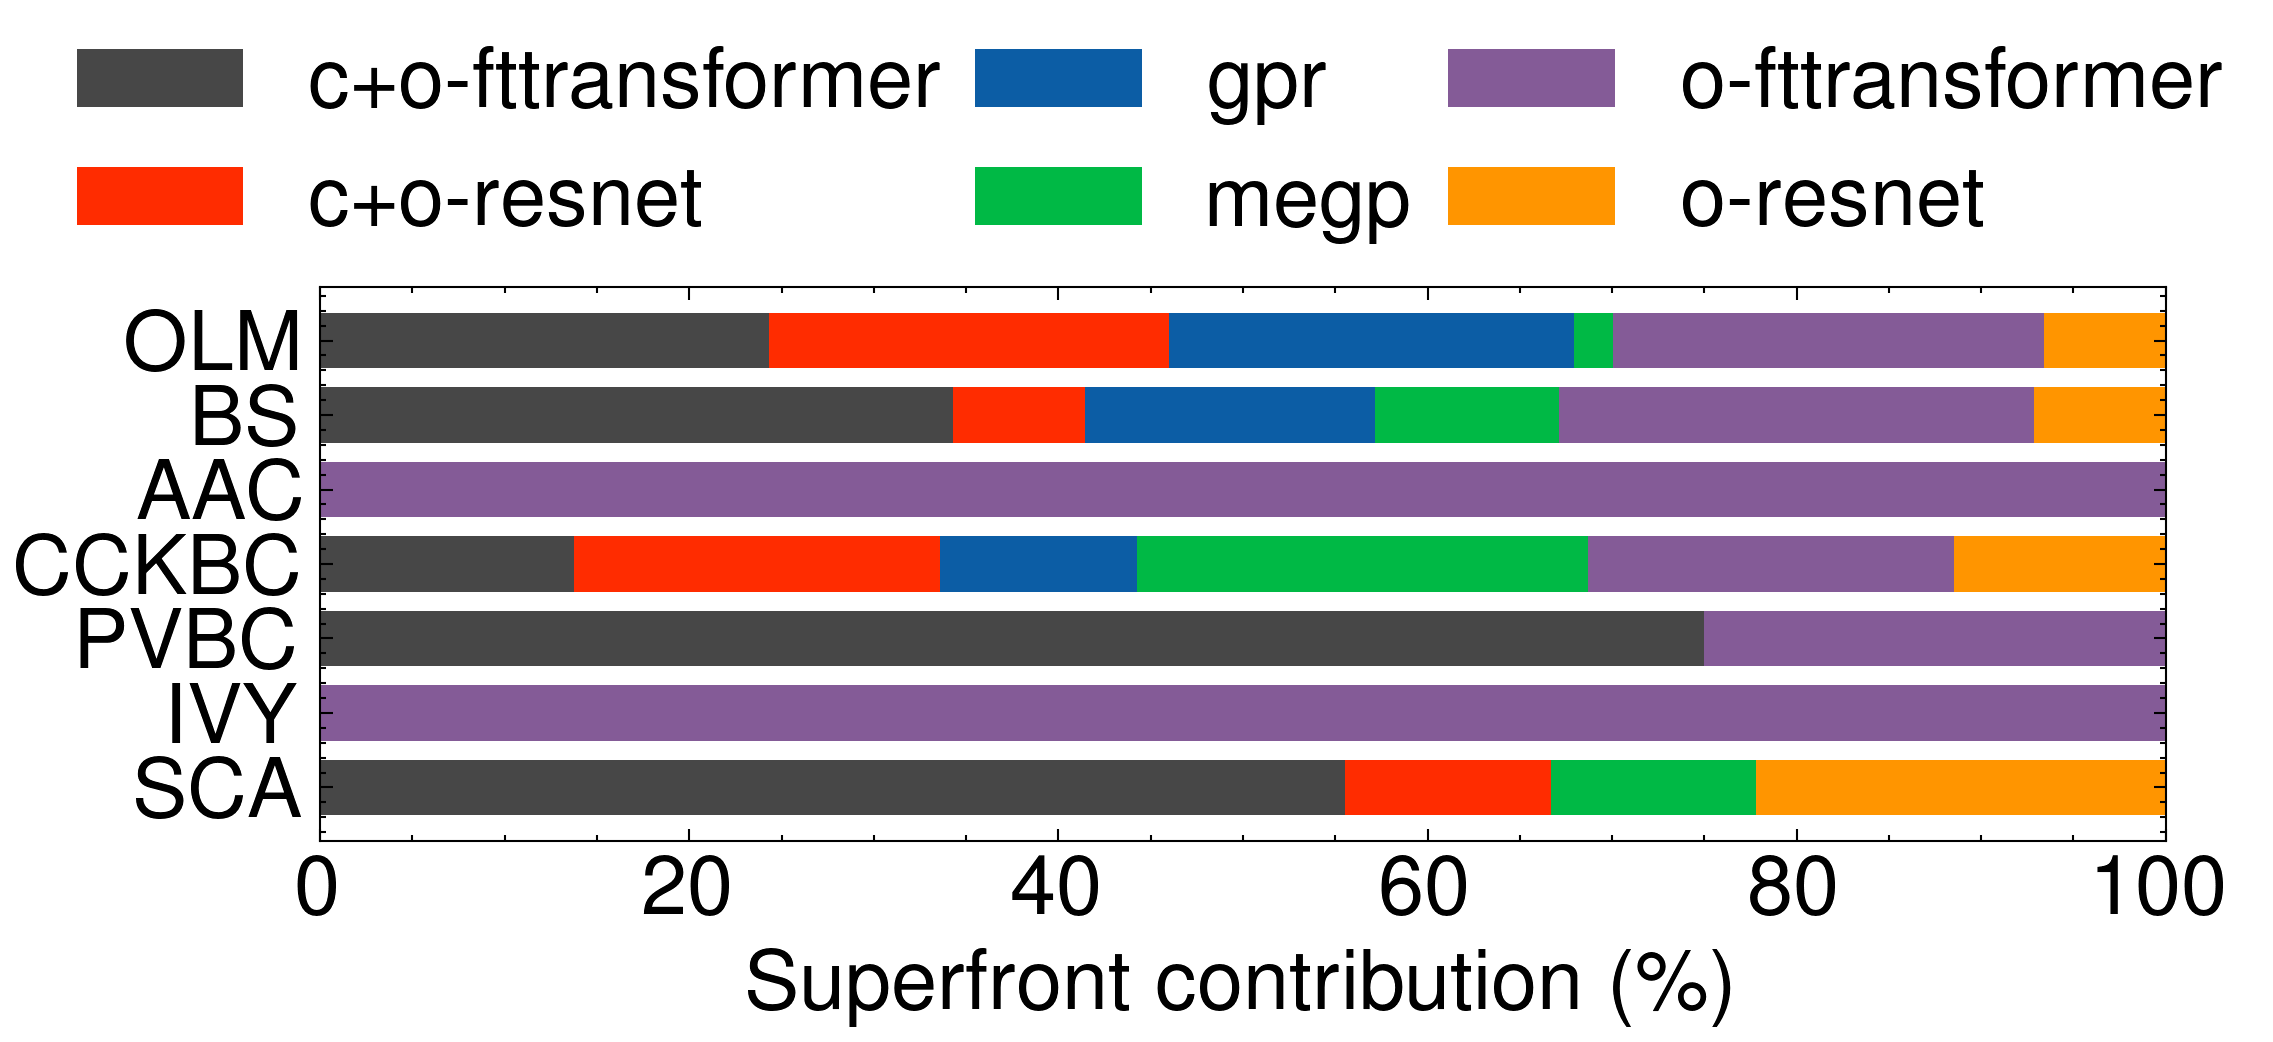

In [26]:
with rc_context():
    fig, ax = plt.subplots(figsize=(8, 4))

    populations_sf = superfront_data["populations"]
    names = superfront_data["names"]
    bars = superfront_data["bars"]

    offset = np.zeros(len(populations_sf))
    for name in names:
        bar = np.array(bars[name])
        ax.barh(
            populations_sf,
            bar,
            align="center",
            left=offset,
            height=0.75,
            label=name,
            color=mcolors.get(name, None),
        )
        offset += bar

    ax.set_xlabel("Superfront contribution (\%)")
    ax.legend(
        bbox_to_anchor=(-0.15, 1.02, 1.2, 2),
        loc="lower left",
        mode="expand",
        borderaxespad=0,
        ncol=min(len(names), 3),
    )

    plt.tight_layout()
    plt.show()


In [ ]:
stash("supplementary/figure-superfront-composition", fig)

# Full Surrogate Training Time Comparison

In [14]:
timing_metrics = restore("figure2-timing_metrics")

In [ ]:
tt = {}
for p, d in timing_metrics.items():
    for model, dd in d.items():
        tt.setdefault(model, {})
        for v, ddd in dd.items():
            tt[model].setdefault(v, [])
            tt[model][v] += ddd

for model in tt:
    for k in [kk for kk in tt[model].keys() if "_" not in kk]:
        tt[model][f"{k}_mean"] = np.mean(tt[model][k])
        tt[model][f"{k}_std"] = np.std(tt[model][k])
        tt[model][f"{k}_u"] = ufloat(tt[model][f"{k}_mean"], tt[model][f"{k}_std"])

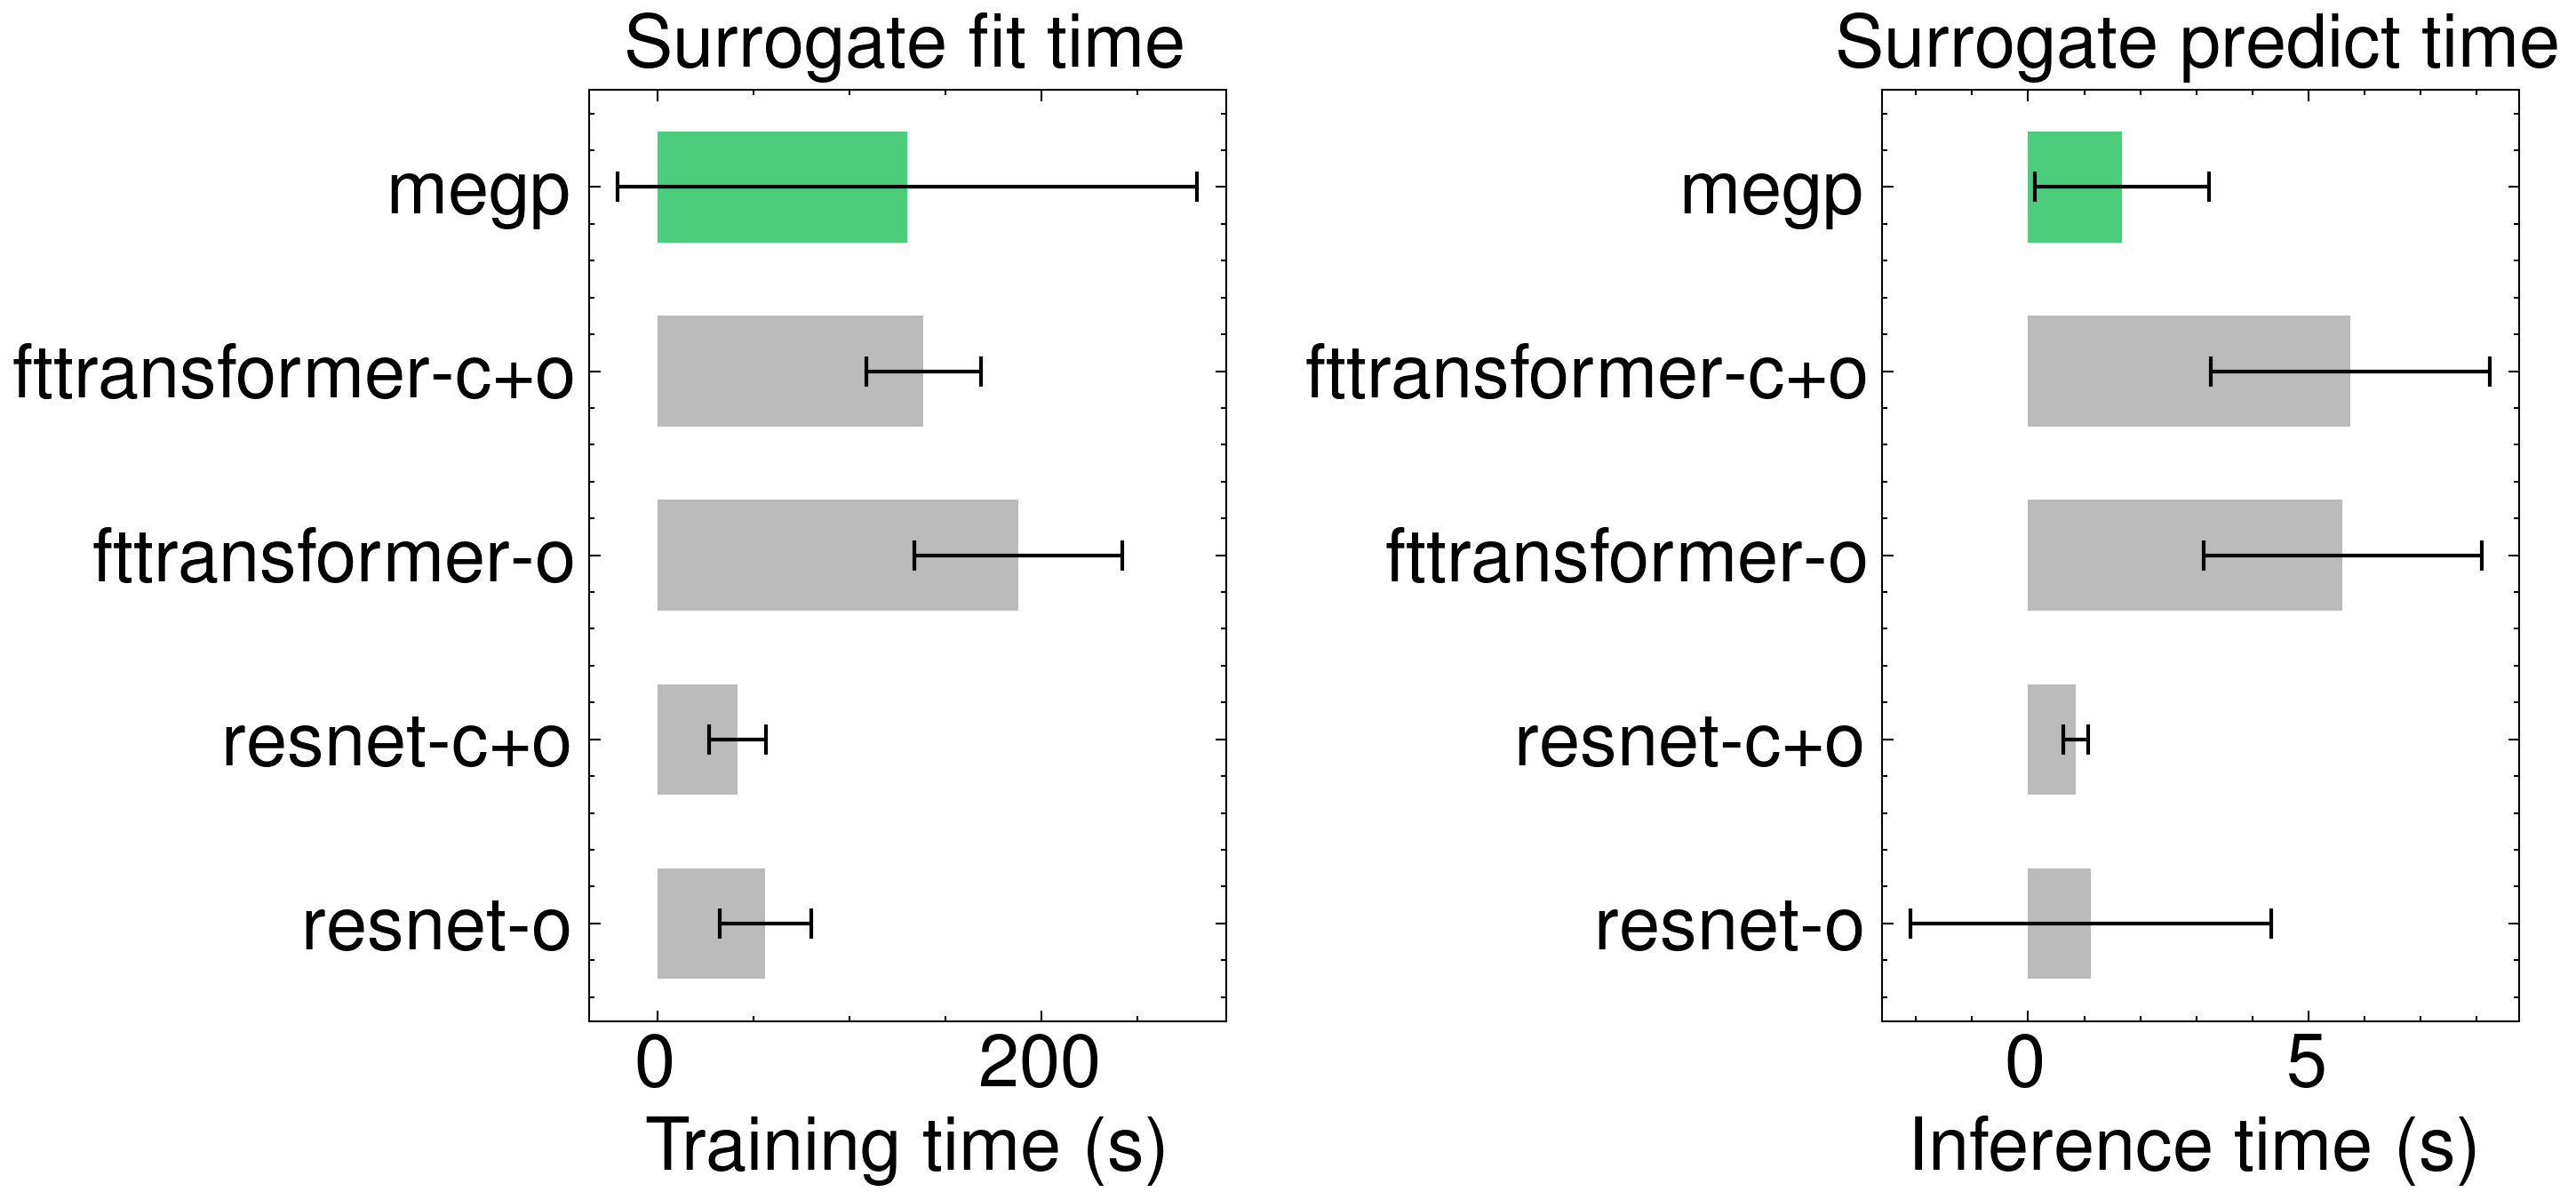

In [ ]:
with rc_context():
    model_keys = list(tt.keys())
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    ax = axs[0]
    y_pos = np.arange(len(model_keys))
    fit_means = [tt[m]["fit_mean"] for m in model_keys]
    fit_stds = [tt[m]["fit_std"] for m in model_keys]
    bars = ax.barh(
        y_pos,
        fit_means,
        xerr=fit_stds,
        capsize=4,
        alpha=0.7,
        color=[mcolors.get(m, colors["grey"]) for m in model_keys],
        height=0.6,
    )
    ax.set_yticks(y_pos)
    ax.set_yticklabels(model_keys)
    ax.set_xlabel("Training time (s)")
    ax.set_title("Surrogate fit time")

    ax = axs[1]
    predict_means = [tt[m]["predict_mean"] for m in model_keys]
    predict_stds = [tt[m]["predict_std"] for m in model_keys]
    bars = ax.barh(
        y_pos,
        predict_means,
        xerr=predict_stds,
        capsize=4,
        alpha=0.7,
        color=[mcolors.get(m, colors["grey"]) for m in model_keys],
        height=0.6,
    )
    ax.set_yticks(y_pos)
    ax.set_yticklabels(model_keys)
    ax.set_xlabel("Inference time (s)")
    ax.set_title("Surrogate predict time")

    plt.tight_layout()
    plt.show()



#  Offline Feasibility Model Analysis

In [ ]:
import os
import pickle

results_dir = ".cache/results/q"

total = 0
total_was_feasible = 0
total_made_feasible = 0
total_destroyed = 0
total_kept_feasible = 0
total_wrong_believes = 0

was_feasible_all = []
believed_feasible_all = []
is_feasible_all = []
destroyed_all = []

for ffn in sorted(os.listdir(results_dir)):
    fn = os.path.join(results_dir, ffn)
    if not fn.endswith(".p") or not os.path.isfile(fn):
        continue

    with open(fn, "rb") as f:
        d = pickle.load(f)

    was_feasible = (d["y_prime"] > 0.99).all(axis=1)
    believed_feasible = (d["y_pred"] > 0.99).all(axis=1)
    is_feasible = np.array([(e[-1] > 0.99).all() for e in d["evals"]])

    destroyed = np.zeros_like(was_feasible, dtype=int)
    kept_feasible = np.zeros_like(was_feasible, dtype=int)
    made_feasible = np.zeros_like(was_feasible, dtype=int)

    made_feasible[(~was_feasible) & is_feasible] = 1
    destroyed[(was_feasible) & (~believed_feasible) & (~is_feasible)] = 1
    kept_feasible[(was_feasible) & (~believed_feasible) & is_feasible] = 1

    was_feasible_all.append(was_feasible)
    believed_feasible_all.append(believed_feasible)
    is_feasible_all.append(is_feasible)
    destroyed_all.append(destroyed)

    total += len(d["y_prime"])
    total_was_feasible += was_feasible.sum()
    total_made_feasible += made_feasible.sum()
    total_destroyed += destroyed.sum()
    total_kept_feasible += kept_feasible.sum()
    total_wrong_believes += (believed_feasible != was_feasible).sum()

was_feasible_all = np.concatenate(was_feasible_all)[:2500]
believed_feasible_all = np.concatenate(believed_feasible_all)[:2500]
is_feasible_all = np.concatenate(is_feasible_all)[:2500]
destroyed_all = np.concatenate(destroyed_all)[:2500]

print(f"Total: {total}")
print(f"Was feasible: {total_was_feasible}")
print(f"Destroyed: {total_destroyed}")
print(f"Kept feasible: {total_kept_feasible}")
print(f"Made feasible: {total_made_feasible}")
print(f"Wrong beliefs: {total_wrong_believes}")

In [ ]:
was_feasible_all = np.array(offline_data["was_feasible"])
believed_feasible_all = np.array(offline_data["believed_feasible"])
is_feasible_all = np.array(offline_data["is_feasible"])
destroyed_all = np.array(offline_data["destroyed"])
totals = offline_data["totals"]

n_initial = 25000
iterations = np.arange(len(was_feasible_all)) + n_initial
y_offset_factor = [8, 6, 4, 2]
y_offset = np.ones(len(was_feasible_all))

with rc_context():
    fig = plt.figure(figsize=(16, 5))
    size = 2500

    cmap_green = matplotlib.colors.ListedColormap(["lightgrey", "forestgreen"])
    cmap_blue = matplotlib.colors.ListedColormap(["lightgrey", "blue"])
    cmap_red = matplotlib.colors.ListedColormap(["lightgrey", "red"])

    plt.scatter(
        iterations, y_offset * y_offset_factor[0],
        c=was_feasible_all, cmap=cmap_green, marker="|", s=size,
    )
    plt.scatter(
        iterations, y_offset * y_offset_factor[1],
        c=believed_feasible_all, cmap=cmap_blue, marker="|", s=size,
    )
    plt.scatter(
        iterations, y_offset * y_offset_factor[2],
        c=is_feasible_all, cmap=cmap_green, marker="|", s=size,
    )
    plt.scatter(
        iterations, y_offset * y_offset_factor[3],
        c=destroyed_all, cmap=cmap_red, marker="|", s=size,
    )

    plt.yticks(
        y_offset_factor,
        [
            f"Was feasible ({totals['was_feasible']})",
            f"Predicted feasible ({int(believed_feasible_all.sum())})",
            f"Now feasible ({int(is_feasible_all.sum())})",
            f"Now infeasible ({int(destroyed_all.sum())})",
        ],
    )
    plt.ylim(0, 10)
    plt.xlabel("Sample index")
    plt.tight_layout()
    plt.show()

In [ ]:
stash("supplementary/figure-offline-feasibility", fig)